In [44]:
!pip install librosa soundfile audioread pandas matplotlib tqdm


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Sel 2: Import Library
import os
import librosa
import librosa.display
import soundfile as sf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# import warnings

# Pengaturan agar notebook tidak terganggu pesan peringatan
# warnings.filterwarnings('ignore', category=FutureWarning)
print("Library berhasil di-import.")

Library berhasil di-import.


In [49]:
# Sel 3: Load Data & Verifikasi Lokasi
data_path = '../Data/genres_original'

# Mengecek apakah path sudah benar
if os.path.exists(data_path):
    print(f"Data ditemukan di: {data_path}")
    # print(f"Data ditemukan di: {os.path.abspath(data_path)}")
    
    # Mencari list genre
    genres = [g for g in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, g))]
    print(f"Daftar Genre: {genres}")
    print(f"Total Genre: {len(genres)}")
else:
    print(f"Error: Folder tidak ditemukan di {data_path}. Pastikan folder 'Data' berada di root directory.")

Data ditemukan di: ../Data/genres_original
Daftar Genre: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total Genre: 10


Scanning files: 100%|██████████| 9990/9990 [00:03<00:00, 2556.61it/s]
C:\Users\Farand\AppData\Local\Temp\ipykernel_6448\4257906936.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Genre', data=df_eda, palette='viridis')


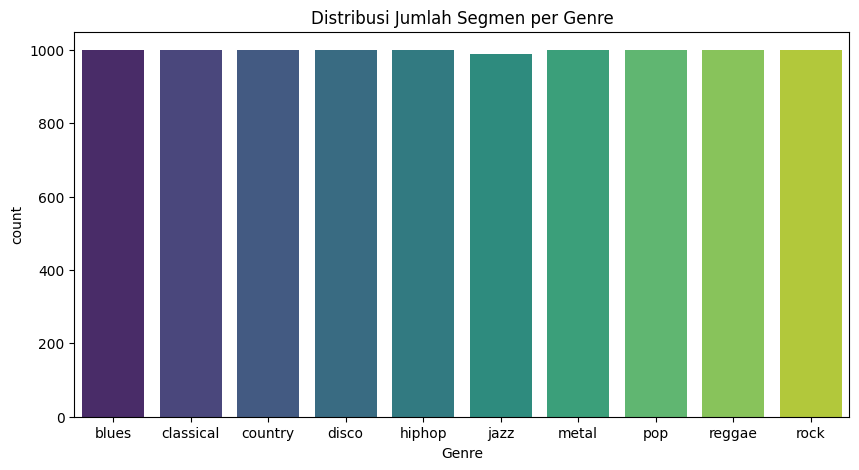

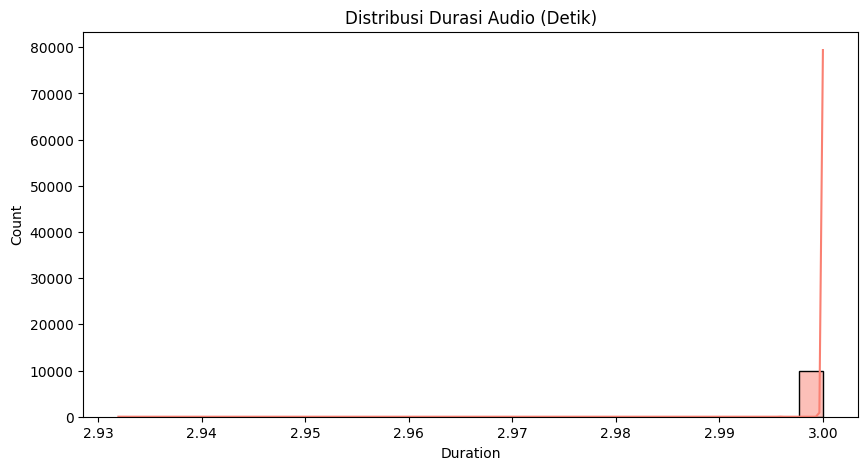

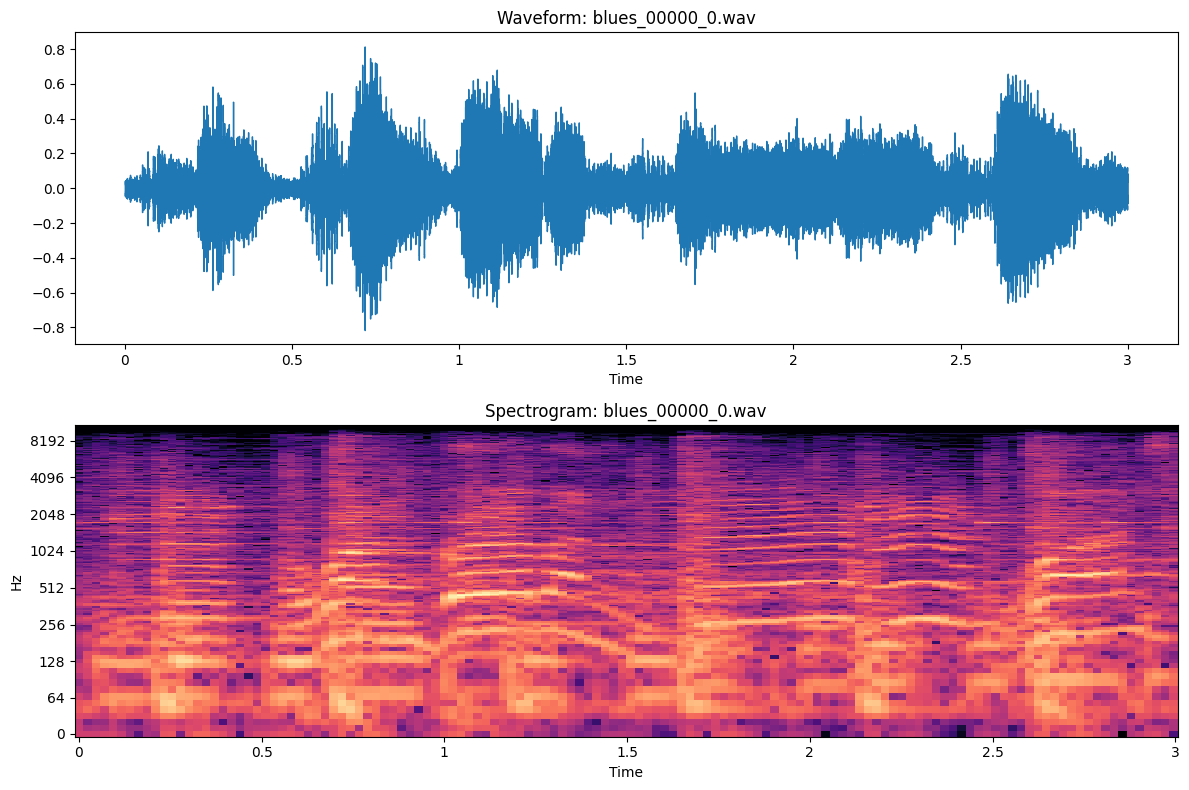

In [4]:
# Sel 4: Eksplorasi Data (EDA)
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
audio_dir = '../Data/segmented_audio'
files = [f for f in os.listdir(audio_dir) if f.endswith('.wav')]

# 1. Mengumpulkan data untuk statistik
data_eda = []
for file in tqdm(files, desc="Scanning files"):
    genre = file.split('_')[0]
    # Mengambil durasi
    duration = librosa.get_duration(path=os.path.join(audio_dir, file))
    data_eda.append({'Genre': genre, 'Duration': duration})

df_eda = pd.DataFrame(data_eda)

# 2. Distribusi Kelas (Jumlah file per genre)
plt.figure(figsize=(10, 5))
sns.countplot(x='Genre', data=df_eda, palette='viridis')
plt.title('Distribusi Jumlah Segmen per Genre')
plt.show()

# 3. Distribusi Durasi Audio
plt.figure(figsize=(10, 5))
sns.histplot(df_eda['Duration'], bins=30, kde=True, color='salmon')
plt.title('Distribusi Durasi Audio (Detik)')
plt.show()

# 4. Contoh Waveform & Spectrogram (Satu Genre Contoh: 'blues')
blues_files = [f for f in files if f.startswith('blues')]
sample_file = os.path.join(audio_dir, blues_files[0])
y, sr = librosa.load(sample_file, sr=22050)

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set_title(f'Waveform: {blues_files[0]}')

# Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax[1])
ax[1].set_title(f'Spectrogram: {blues_files[0]}')
plt.tight_layout()
plt.show()

In [2]:
# Sel 5: Segmentasi Audio
input_dir = '../Data/genres_original'
output_dir = '../Data/segmented_audio'

# Pastikan folder output ada
os.makedirs(output_dir, exist_ok=True)

# Mendapatkan list genre
genres = [g for g in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, g))]

print("Memulai proses segmentasi (memotong setiap audio menjadi 10 bagian)...")

for genre in genres:
    genre_path = os.path.join(input_dir, genre)
    
    # tqdm memberikan bar progress agar kita tahu proses berjalan
    for file in tqdm(os.listdir(genre_path), desc=f"Genre: {genre}"):
        if file.endswith('.wav'):
            file_path = os.path.join(genre_path, file)
            
            try:
                # Load audio
                y, sr = librosa.load(file_path, sr=22050)
                
                # 3 detik * 22050 Hz = 66150 sampel
                samples_per_segment = 3 * sr
                
                # Loop untuk memotong menjadi 10 segmen
                for i in range(10):
                    start = i * samples_per_segment
                    end = start + samples_per_segment
                    segment = y[start:end]
                    
                    # Simpan segmen
                    # Format: genre_filename_segmentIndex.wav
                    output_filename = f"{genre}_{file.split('.')[1]}_{i}.wav"
                    sf.write(os.path.join(output_dir, output_filename), segment, sr)
            
            except Exception as e:
                print(f"\nGagal memproses {file}: {e}")

print("\nSegmentasi selesai! Semua file 3 detik tersimpan di folder 'Data/segmented_audio'.")

Memulai proses segmentasi (memotong setiap audio menjadi 10 bagian)...


Genre: blues:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Farand\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Genre: jazz:  54%|█████▍    | 54/100 [00:02<00:02, 21.72it/s]C:\Users\Farand\AppData\Local\Temp\ipykernel_6448\3963260219.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050)
C:\Users\Farand\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Genre: jazz:  58%|█████▊    | 58/100 [00:02<00:01, 23.89it/s]


Gagal memproses jazz.00054.wav: 


Genre: rock: 100%|██████████| 100/100 [00:04<00:00, 24.62it/s]


Segmentasi selesai! Semua file 3 detik tersimpan di folder 'segmented_audio'.


In [52]:
# Sel 6: Verifikasi Jumlah File
output_dir = '../Data/segmented_audio'

if os.path.exists(output_dir):
    files = [f for f in os.listdir(output_dir) if f.endswith('.wav')]
    total_files = len(files)
    print(f"Total file segmen audio yang berhasil dibuat: {total_files}")
    
    # Melihat contoh struktur nama file
    print(f"Contoh nama file: {files[0]}")
else:
    print("Folder 'segmented_audio' tidak ditemukan!")

Total file segmen audio yang berhasil dibuat: 9990
Contoh nama file: blues_00000_0.wav


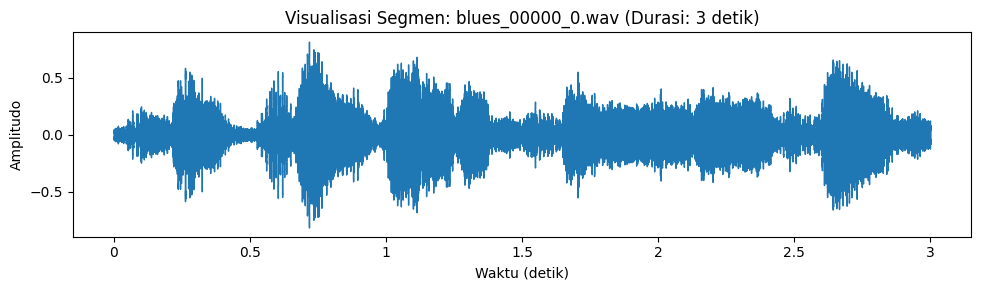

In [53]:
# Sel 7: Visualisasi Segmen Audio
import matplotlib.pyplot as plt
import librosa.display

# Cari satu file yang diawali dengan 'blues' untuk visualisasi
audio_dir = '../Data/segmented_audio'
file_target = [f for f in os.listdir(audio_dir) if f.startswith('blues')][0]
file_path = os.path.join(audio_dir, file_target)

# Load audio segmen
y, sr = librosa.load(file_path, sr=22050)

# Plot bentuk gelombang
plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Visualisasi Segmen: {file_target} (Durasi: 3 detik)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

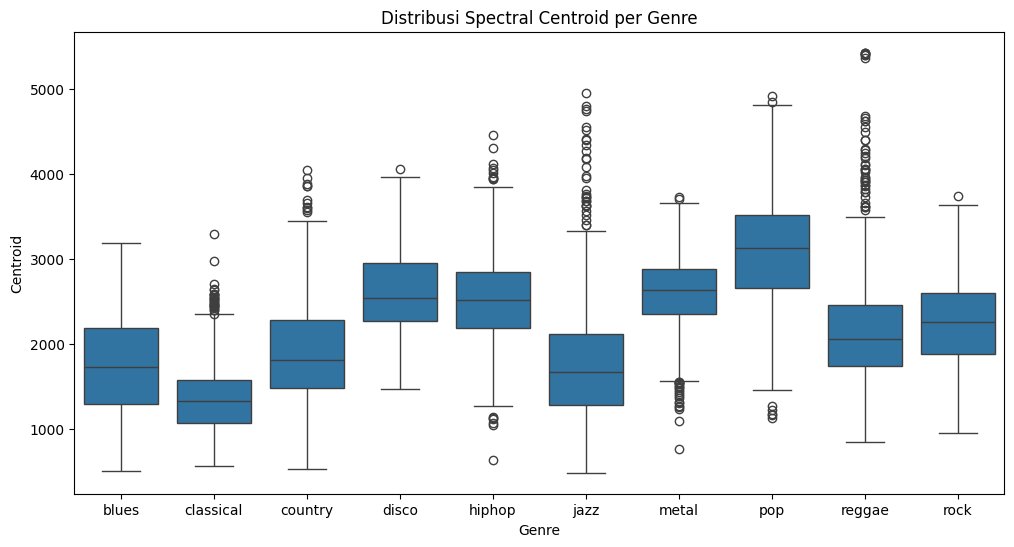

In [5]:
data_spectral = []
for file in files:
    y, sr = librosa.load(os.path.join(audio_dir, file), sr=22050)
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    data_spectral.append({'Genre': file.split('_')[0], 'Centroid': np.mean(cent)})

df_spectral = pd.DataFrame(data_spectral)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Genre', y='Centroid', data=df_spectral)
plt.title('Distribusi Spectral Centroid per Genre')
plt.show()